In [2]:
import pandas as pd
import numpy as np
import commodity_common_functions as CCF
import seaborn as sns
import dataframe_image as dfi
from pathlib import Path
import json
import datetime as dt
import logging
from datetime import datetime
import OptionRiskMetrixETF as ORME
import OptionRiskMetrix as ORM

ModuleNotFoundError: No module named 'pymongo'

In [2]:
date = '20250513'
datebar = '2025-05-13'
SQL_cmd = f"""
SELECT instrument_id, close, volume, open_interest, underlying_instr_id
FROM daily_data_option
WHERE trading_date = '{date}'
ORDER BY open_interest DESC
"""
optionprice = pd.read_sql(sql=SQL_cmd, con=CCF.std_market_data)

In [3]:
SQL_cmd = f"""
SELECT instrument_id as underlying_instr_id, product_id, close, volume, open_interest
FROM daily_data 
WHERE instrument_id IN {tuple(optionprice['underlying_instr_id'])} AND trading_date = '{datebar}'
"""
futureprice = pd.read_sql(sql=SQL_cmd, con=CCF.std_market_data)

In [4]:
SQL_cmd = f"""
SELECT instrument_id, exchange_id, strike_price, options_type
FROM instrument 
WHERE instrument_id IN {tuple(optionprice['instrument_id'])}
"""
insinfo = pd.read_sql(sql=SQL_cmd, con=CCF.market_base)
insinfo['options_type'] = insinfo['options_type'].map({'1': 'c', '2': 'p'})

In [5]:
df = optionprice.merge(futureprice, on='underlying_instr_id', how='left', suffixes=('_option', '_future'))
df = df.merge(insinfo, on='instrument_id', how='left')
df = df[df['exchange_id'] == 'DCE'].dropna().reset_index(drop=True)

In [6]:
# Group by product_id and underlying_instr_id, sum volume_option, then get max for each product_id
max_volume_df = df.groupby(['product_id', 'underlying_instr_id'])['open_interest_future'].sum().reset_index()
max_volume_df = max_volume_df.loc[max_volume_df.groupby('product_id')['open_interest_future'].idxmax()]
df = df[df['underlying_instr_id'].isin(max_volume_df['underlying_instr_id'])]

In [7]:
df['moneyness'] = df['strike_price']/df['close_future']
df['defi'] = np.where((df['moneyness'] > 0.99) & (df['moneyness'] < 1.01), 'ATM', 'ITM')
df['defi'] = np.where((df['moneyness'] > 1.01) & (df['options_type'] == 'c'), 'OTM', df['defi'])
df['defi'] = np.where((df['moneyness'] < 0.99) & (df['options_type'] == 'p'), 'OTM', df['defi'])

In [8]:
# Calculate volume percentages by defi for each underlying
volume_pct = df.groupby(['underlying_instr_id', 'defi'])['volume_option'].sum().unstack()
volume_pct = volume_pct.div(volume_pct.sum(axis=1), axis=0) * 100

# Calculate open interest percentages by defi for each underlying
oi_pct = df.groupby(['underlying_instr_id', 'defi'])['open_interest_option'].sum().unstack()
oi_pct = oi_pct.div(oi_pct.sum(axis=1), axis=0) * 100

# Display both results
print("Volume percentages by defi:")
print(volume_pct)

Volume percentages by defi:
defi                       ATM        ITM        OTM
underlying_instr_id                                 
a2507                13.944033   1.387228  84.668740
b2509                16.807470   6.447310  76.745220
c2507                15.026701   5.480886  79.492413
cs2507               29.796422   8.901031  61.302547
eb2506               22.661716  10.701864  66.636420
eg2509               21.062461  19.049595  59.887944
i2509                10.906271   4.832763  84.260966
jd2507               18.784680   4.303695  76.911625
l2509                16.104594  11.852395  72.043011
lg2507                     NaN   7.158837  92.841163
lh2509               20.000000   2.772277  77.227723
m2509                 9.904638   4.271263  85.824098
p2509                 7.830552   6.531878  85.637570
pg2506                7.278493   4.238751  88.482756
pp2509                2.902130   3.190285  93.907585
v2509                12.272148   1.815318  85.912535
y2509             

In [12]:
oi_pct.to_csv('./temp/oi_pct.csv')

In [13]:
volume_pct.to_csv('./temp/volume_pct.csv')

In [50]:
import matplotlib.pyplot as plt
future_id = 'v2506'
quotecsv = pd.read_csv(f'D://商品期权//CVIX//20250513//{future_id}.csv')
quotecsv.index = quotecsv['Updatetime']
quotecsv = quotecsv.iloc[5:-5,:]
tick_size = 0.5
itmk = '5000.0p'
otmk = '4700.0p'


In [40]:
quotec'itmk_ask'] = quotecsv[f'{itmk}_ask']/tick_size


Index(['Unnamed: 0', 'Updatetime', 'und_price', 'ttm', '670.0c', '670.0c_ask',
       '670.0c_bid', '580.0p', '580.0p_ask', '580.0p_bid',
       ...
       '900.0c_ask', '900.0c_bid', '920.0c', '920.0c_ask', '920.0c_bid',
       '850.0p', '850.0p_ask', '850.0p_bid', 'variance', 'IV'],
      dtype='object', length=153)

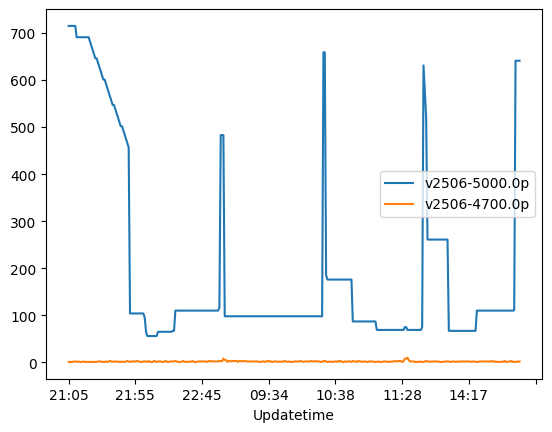

In [51]:
result = pd.DataFrame()
result[f'{future_id}-{itmk}'] = ((quotecsv[f'{itmk}_ask']-quotecsv[f'{itmk}_bid'])/tick_size)
result[f'{future_id}-{otmk}'] = ((quotecsv[f'{otmk}_ask']-quotecsv[f'{otmk}_bid'])/tick_size)
result.plot()
plt.savefig(f'./temp/DCE/{future_id}-result.png')


In [52]:
result.describe().to_csv(f'./temp/DCE/{future_id}-result.csv')


In [ ]:
quotecsv
tick_size = 0.5


,Unnamed: 0,Updatetime,und_price,ttm,2700.0c,2700.0c_ask,2700.0c_bid,2400.0p,2400.0p_ask,2400.0p_bid,...,2850.0c_ask,2850.0c_bid,2800.0c,2800.0c_ask,2800.0c_bid,3150.0p,3150.0p_ask,3150.0p_bid,variance,IV
0,0,21:00,2909.5,0.283951,232.0,245.5,207.0,4.0,4.5,4.0,...,134.5,104.0,159.5,168.5,133.5,276.5,281.5,213.0,0.030834,0.156262
1,1,21:01,2908.5,0.283939,232.0,245.5,229.0,4.0,4.5,4.0,...,134.5,123.5,158.5,168.5,155.5,276.5,281.5,274.0,0.031065,0.159632
2,2,21:02,2907.5,0.283927,232.0,245.5,229.0,4.0,4.5,4.0,...,134.5,123.5,158.5,168.5,155.5,276.5,283.0,275.5,0.031380,0.158092
3,3,21:03,2905.5,0.283915,232.0,245.5,228.0,4.0,4.5,4.0,...,132.0,124.5,157.5,168.5,155.5,280.0,283.0,277.0,0.031381,0.159499
4,4,21:04,2905.5,0.283903,231.5,232.5,230.0,4.0,4.5,4.0,...,127.5,125.5,157.5,158.0,155.5,280.0,283.0,277.0,0.031183,0.157868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,344,14:56,2887.5,0.279883,215.0,217.0,214.0,4.0,4.0,3.5,...,116.0,114.0,143.0,144.5,142.0,288.0,300.5,288.0,0.030600,0.158887
345,345,14:57,2889.5,0.279871,217.0,218.5,215.5,4.0,4.0,3.5,...,117.0,115.0,144.5,145.5,143.5,288.0,300.5,288.0,0.030628,0.158399
346,346,14:58,2888.5,0.279859,215.0,217.5,215.0,4.0,4.0,3.5,...,116.5,114.5,143.0,145.0,143.0,288.0,300.5,288.0,0.030636,0.158033
347,347,14:59,2887.5,0.279847,215.0,216.5,214.0,4.0,4.0,3.5,...,116.0,113.0,143.0,144.5,141.5,288.0,300.5,288.0,0.030637,0.159308


In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
k_lst = np.array([3800., 3850., 3900., 3950., 4000., 4100., 4150., 4200., 4250.,
       4300., 4350., 4400., 4450., 4500., 4550., 4600., 4650., 4700.,
       4750., 4800., 4850., 4900., 4950., 5000., 5100., 5200., 5300.,
       5400., 5500., 5600., 5700., 5800.])
iv_lst = np.array([0.37495146, 0.31276287, 0.32029264, 0.31094772, 0.28457099,
       0.26309609, 0.25520747, 0.24472726, 0.22551847, 0.21854455,
       0.20347555, 0.19514361, 0.18912357, 0.18281155, 0.17848592,
       0.1792487 , 0.18009607, 0.18210998, 0.18999738, 0.19810501,
       0.2090798 , 0.21874794, 0.23056542, 0.24259282, 0.26185027,
       0.28569282, 0.30199649, 0.31821827, 0.33218038, 0.3538559 ,
       0.36733294, 0.37446763])
und_price = 4779

lnk = np.log(k_lst/und_price)
initial_paras = [0.04, 0.4, 0.1, -0.4, 0]
def fit_svi(paramt):
    a, b, sigma, rho, m = paramt
    var_ = a + b * (rho * (lnk - m) + np.sqrt(np.square(lnk - m) + sigma ** 2))
    return np.sum(np.abs(var_ - np.square(iv_lst)))
res = optimize.minimize(fit_svi, initial_paras, method='BFGS', tol=1e-12)
paras = res.x
testklst = np.linspace(3800, 5800, 1000)
lnmtest = np.log(testklst/und_price)
a, b, sigma, rho, m = paras
var_t = a + b * (rho * (lnmtest - m) + np.sqrt(np.square(lnmtest - m) + sigma ** 2))
iv_test = np.sqrt(var_t)
plt.plot(testklst, iv_test)
plt.scatter(k_lst, iv_lst)



In [2]:
testklst = np.linspace(3800, 5800, 1000)
lnmtest = np.log(testklst/und_price)
a, b, sigma, rho, m = paras
var_t = a + b * (rho * (lnmtest - m) + np.sqrt(np.square(lnmtest - m) + sigma ** 2))
iv_test = np.sqrt(var_t)


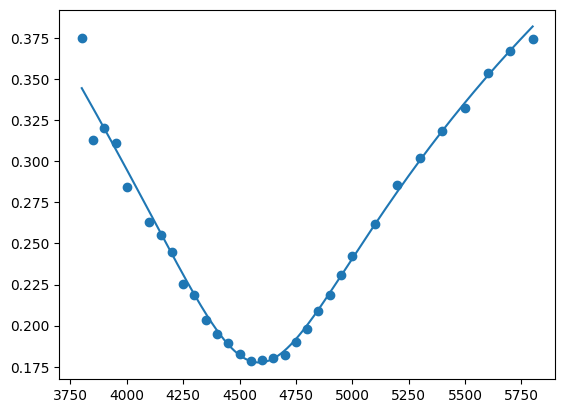

In [3]:
plt.plot(testklst, iv_test)
plt.scatter(k_lst, iv_lst)